<a href="https://colab.research.google.com/github/DanchiTum/AI/blob/pr3/Task3_basic_ai_ad_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Лабораторна робота №3.
***Data Pre-Processing***

Оцінювання даної роботи буде ураховувати якість ваших візуалізацій (вони можуть незначно відрізнятися від прикладів, але повинні змістовно відображати суть задачі) та опис отриманих вами результатів. При наявності ЛИШЕ візуалізацій без роз'яснень, робота оцінюватися НЕ БУДЕ.

Під час виконання вам дозволено користуватися будь-якими зручними для вас бібліотеками для візуалізації.

Роботи ідентифіковані як ІДЕНТИЧНІ одразу отримують 0 балів.

Для виконання цієї лабораторної роботи Вам необхідно скористатися вибіркою [titanic.csv](https://gist.github.com/michhar/2dfd2de0d4f8727f873422c5d959fff5).  
Цей датасет ви вже використовували в лабораторній роботі №1 ;)  
  
  ```NB:побудовані графіки та гістограми мають бути змістовними і візуально зрозумілими.```

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder



sns.set_theme(style="whitegrid")
sns.set_context('talk')

***Завдання 1.*** Перед початком роботи з будь яким датасетом, необхідно:  
- завантажити датасет;  
- вивести основну статистичну інформацію по числовим змінним;
- вивести розмірність датасету;
- перевірити типи змінних і кількість данних по кожній змінній.

In [ ]:
dataset = pd.read_csv('titanic.csv')

In [ ]:
print(dataset.describe())

print(dataset.shape)

print(dataset.info())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  
(891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890

***Завдання 2.*** Визначити кількість пропущених значень по кожному атрибуту

In [ ]:
missing_values = dataset.isnull().sum()
print(missing_values)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


Ваші висновки:

Практично всі атрибути заповнені, стовпці PassengerId, Survived, Pclass, Name, Sex, SibSp, Parch, Ticket і Fare не мають пропущених значень, тільки атрибути Age має 177 пропущених значень, Cabin — 687, а Embarked — лише 2.

***Завдання 3:*** Побудувати матрицю кореляції



1.   Вирахувати кореляційні коефіціенти для набору данних за методом Пірсона
2.   Відобразити отриману матрицю коефіціентів у вигляді теплокарти

3. Описати отримані результати, спираючись на значення коефіціентів кореляції



             PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId     1.000000 -0.005007 -0.035144  0.036847 -0.057527 -0.001652   
Survived       -0.005007  1.000000 -0.338481 -0.077221 -0.035322  0.081629   
Pclass         -0.035144 -0.338481  1.000000 -0.369226  0.083081  0.018443   
Age             0.036847 -0.077221 -0.369226  1.000000 -0.308247 -0.189119   
SibSp          -0.057527 -0.035322  0.083081 -0.308247  1.000000  0.414838   
Parch          -0.001652  0.081629  0.018443 -0.189119  0.414838  1.000000   
Fare            0.012658  0.257307 -0.549500  0.096067  0.159651  0.216225   

                 Fare  
PassengerId  0.012658  
Survived     0.257307  
Pclass      -0.549500  
Age          0.096067  
SibSp        0.159651  
Parch        0.216225  
Fare         1.000000  


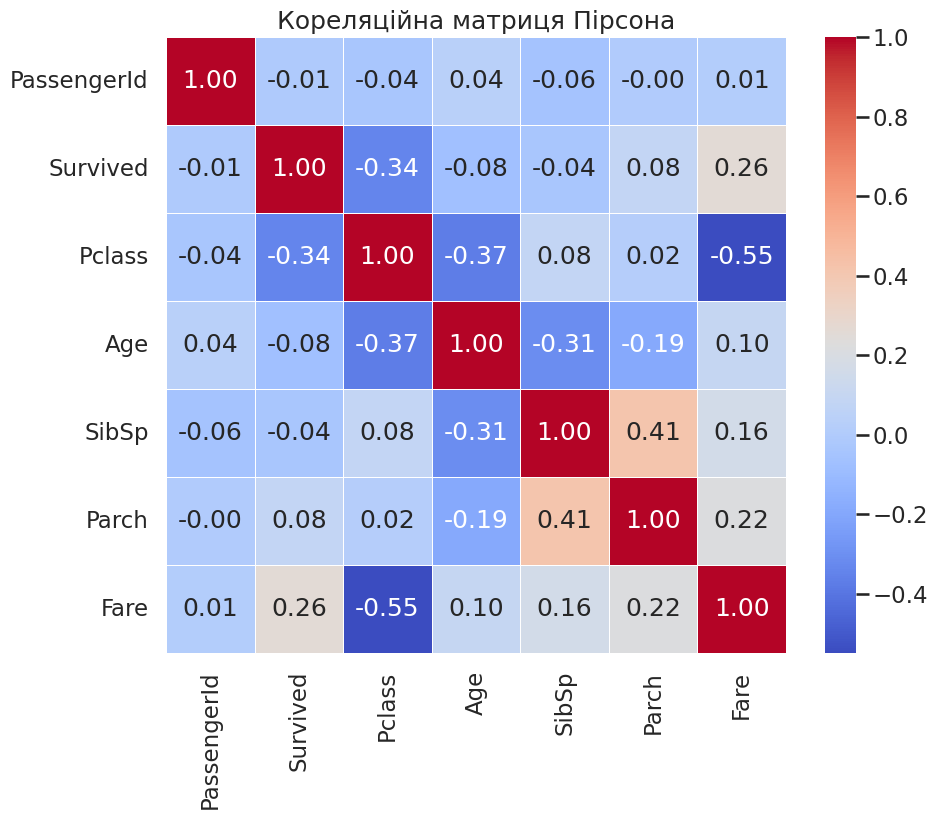

In [ ]:
dataset = dataset.select_dtypes(include=['number'])

correlation_matrix = dataset.corr(method='pearson')

print(correlation_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Кореляційна матриця Пірсона")
plt.show()

Ваші висновки:
виживання пасажирів більше залежить від соціально-економічного статусу (який відображений через Pclass і Fare), а також від того, чи подорожували пасажири із сім’єю.

**Завдання 4:** Як ви могли помітити, у нашому датесеті досить багато пропущених значень, зокрема у атрибута віку пасажирів. Робота з такими даними впливае як на результат моделювання так і на загалом уявлення цілісної картини про дані. Тож для того, що позбавитися пропусків ми використаємо заповнення пропущених значень медіаною за групами.



1.   Напишіть функцію, що на вхід приймає датафрейм, назву колонки з пропущеними значеннями та список групуючих колонок та повертає датафрейм з заповненими пропущеними значеннями
2.   Наведіть приклад роботи функції та зробіть перевірку на пропущені значення (дивись **завдання 2**)



In [ ]:

def fill_missing_by_group_median(dataset, target_column, group_columns):
    """
    params
    dataset (pandas.DataFrame) join table
    target_column (str) table with NaN
    group_columns (list)

    return
    pandas.DataFrame
    """
    missing_columns = [col for col in [target_column] + group_columns if col not in dataset.columns]
    if missing_columns:
        raise ValueError(f"колонки {missing_columns} відсутні в датафреймі "
                        f"доступні колонки {list(dataset.columns)}")

    dataset_filled = dataset.copy()

    try:
        medians = dataset_filled.groupby(group_columns)[target_column].transform('median')

        dataset_filled[target_column] = dataset_filled[target_column].fillna(medians)

        if dataset_filled[target_column].isna().any():
            overall_median = dataset_filled[target_column].median()
            dataset_filled[target_column] = dataset_filled[target_column].fillna(overall_median)

    except Exception as e:
        raise Exception(f"помилка при обробці даних: {str(e)}")

    return dataset_filled

print("Наявні колонки у датафреймі:")
print(dataset.columns.tolist())

print("\nПропущені значення до заповнення:")
print(dataset['Age'].isna().sum())

dataset_filled = fill_missing_by_group_median(dataset, 'Age', ['Pclass'])

print("\nПропущені значення після заповнення:")
print(dataset_filled['Age'].isna().sum())

print("\nМедіани віку по групах (Pclass):")
print(dataset_filled.groupby(['Pclass'])['Age'].median())

Наявні колонки у датафреймі:
['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

Пропущені значення до заповнення:
177

Пропущені значення після заповнення:
0

Медіани віку по групах (Pclass):
Pclass
1    37.0
2    29.0
3    24.0
Name: Age, dtype: float64


Ваші висновки:

Функція, що заповнює пропущені значення медіаною за групами, успішно відсторонила всі пропуски в колонці «Age».

Обчислені медіани віку за класами показують, що пасажири першого класу мають вищий середній вік, за ними другий та третій. Це свідчить про різницю вікових груп серед пасажирів різних класів.


***Завдання 5:*** В моделях машинного навчання інснує велика проблема опрацювання безперервних змінних. Потрібно перетворити безперервні значення в категоріальні.

Максимальний вік пасажира - ```80 років```.

Отже, давайте розділимо діапазон від ```0 до 80``` на ```5``` осередків.


Додайте до нашого датасету нову колонку ```Age_bin```, в якій будуть значення ```0, 1, 2, 3, 4```відповідно кожній віковій групі.

Побудуйте графік, який відображає кількість виживших у кожній віковій категорії.





<Figure size 1000x600 with 0 Axes>

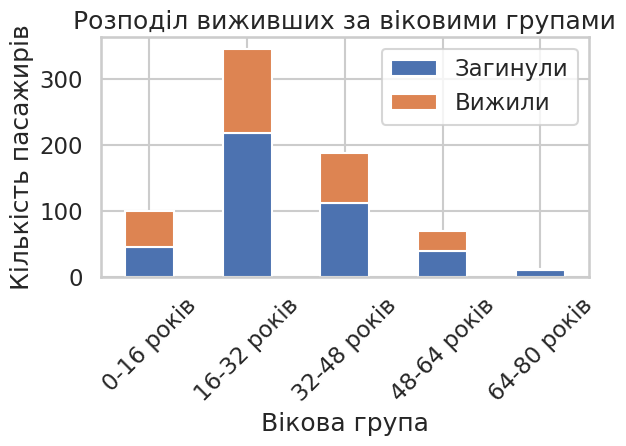

Survived    0    1
Age_bin           
0          45   55
1         218  128
2         112   76
3          39   30
4          10    1


In [ ]:


bins = np.linspace(0, 80, 6)
labels = [0, 1, 2, 3, 4]

dataset['Age_bin'] = pd.cut(dataset['Age'], bins=bins, labels=labels, include_lowest=True)

survival_by_age = dataset.groupby('Age_bin', observed=True)['Survived'].value_counts().unstack()

plt.figure(figsize=(10, 6))
survival_by_age.plot(kind='bar', stacked=True)

plt.title('Розподіл виживших за віковими групами')
plt.xlabel('Вікова група')
plt.ylabel('Кількість пасажирів')
plt.legend(['Загинули', 'Вижили'])

age_ranges = [f"{int(bins[i])}-{int(bins[i+1])} років" for i in range(len(bins)-1)]
plt.xticks(range(len(age_ranges)), age_ranges, rotation=45)

plt.tight_layout()
plt.show()

print(survival_by_age)

Ваші висновки:
Всі значення "Age" були розподілені за 5 групами:

Група 0: 45 невиживших та 55 виживших (55% виживання).

Група 1: 218 невиживших та 128 виживших (~37% виживання).

Група 2: 112 невиживших та 76 виживших (~40% виживання).

Група 3: 39 невиживших та 30 виживших (~43% виживання).

Група 4: 10 невиживших та 1 виживший (~9% виживання).

***Завдання 6:*** Так як змінна ```fare``` також є неперервною її треба закодувати до ```порядкової шкали```
Для цього скоритайтесь функцією ```pandas.qcut```.
[pandas.qcut](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.qcut.html)  
- необхідно перевірити, чи є вірною гіпотеза про те, що кількість виживших пасажирів для квартильних значеннь змінної ```fare``` відрізняється, та чи доцільно використовувати кодування на цю змінну(для подальшої роботи з закодованою фичею)

Таблиця спряженості:
Survived    0    1
Fare_bin          
Q1        179   44
Q2        156   68
Q3        121  101
Q4         93  129

Результати хі-квадрат тесту:
Хі-квадрат статистика: 80.1739
p-значення: 0.0000

Відсоток виживання по квартилях:
Fare_bin
Q1    19.730942
Q2    30.357143
Q3    45.495495
Q4    58.108108
dtype: float64


<Figure size 1000x600 with 0 Axes>

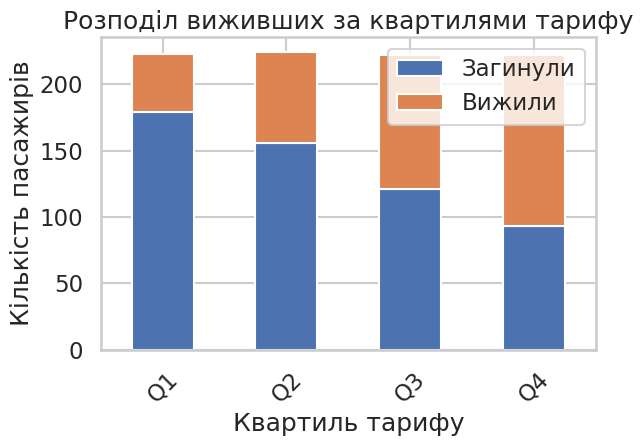

In [ ]:
dataset['Fare_bin'] = pd.qcut(dataset['Fare'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

contingency_table = pd.crosstab(dataset['Fare_bin'], dataset['Survived'])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Таблиця спряженості:")
print(contingency_table)
print("\nРезультати хі-квадрат тесту:")
print(f"Хі-квадрат статистика: {chi2:.4f}")
print(f"p-значення: {p_value:.4f}")

survival_rate = (contingency_table[1] / (contingency_table[0] + contingency_table[1]) * 100)
print("\nВідсоток виживання по квартилях:")
print(survival_rate)

plt.figure(figsize=(10, 6))
contingency_table.plot(kind='bar', stacked=True)
plt.title('Розподіл виживших за квартилями тарифу')
plt.xlabel('Квартиль тарифу')
plt.ylabel('Кількість пасажирів')
plt.legend(['Загинули', 'Вижили'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



Ваші висновки:

Пасажири, що опинилися у вищих квартилях тарифів, мають значно вищий відсоток виживання у порівнянні з тими, хто ввійшов до Q1 та Q2.

***Завдання 7:*** Необхідно створити нові змінні ```Family_size``` та ```Alone``` та проаналізувати їх. Змінна ```Family_size``` передає суму змінних ```Parch``` та ```SibSp```. Змінна ```Family_size``` буде відібражати комбіновані дані, які необхідні для перевірки гіпотези, що ```виживання пасажирів залежіть від кількості членів їх сім'ї```. Змінна ```Alone``` позначає наявніть сім'ї.

In [ ]:
dataset["Family_size"] = dataset["SibSp"] + dataset["Parch"]
dataset["Alone"] = (dataset["Family_size"] == 0).astype(int)

family_survival = dataset.groupby("Family_size")["Survived"].mean()
alone_survival = dataset.groupby("Alone")["Survived"].mean()

print(family_survival)

print(alone_survival)

Family_size
0     0.303538
1     0.552795
2     0.578431
3     0.724138
4     0.200000
5     0.136364
6     0.333333
7     0.000000
10    0.000000
Name: Survived, dtype: float64
Alone
0    0.505650
1    0.303538
Name: Survived, dtype: float64


Ваші висновки:
Обчислена змінна демонструє, що виживання значно варіюється залежно від кількості членів сім'ї, це свідчить про те, що невелика або середня кількість членів сім'ї позитивно впливає на шанси виживання.

***Завдання 8:*** Видалити атрибути які є ***НЕрелевантними*** або містять багато пропущених значень. Аргументувати свій вибір.

In [ ]:
dataset_cleaned = dataset.drop(["PassengerId"], axis=1)

print(dataset_cleaned.head())

   Survived  Pclass   Age  SibSp  Parch     Fare Age_bin Fare_bin  \
0         0       3  22.0      1      0   7.2500       1       Q1   
1         1       1  38.0      1      0  71.2833       2       Q4   
2         1       3  26.0      0      0   7.9250       1       Q2   
3         1       1  35.0      1      0  53.1000       2       Q4   
4         0       3  35.0      0      0   8.0500       2       Q2   

   Family_size  Alone  
0            1      0  
1            1      0  
2            0      1  
3            1      0  
4            0      1  


ідентифікатор, який не впливає на виживання

***Завдання 9:*** Перетворіть змінні ```Sex```, ```Embarked``` та ```Title``` в числові значення


In [ ]:
label_encoder = LabelEncoder()

dataset["Sex"] = label_encoder.fit_transform(dataset["Sex"])
dataset["Embarked"] = label_encoder.fit_transform(dataset["Embarked"])

print(dataset.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name  Sex   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris    1  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    0  38.0      1      0   
2                             Heikkinen, Miss. Laina    0  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)    0  35.0      1      0   
4                           Allen, Mr. William Henry    1  35.0      0      0   

             Ticket     Fare Cabin  Embarked  
0         A/5 21171   7.2500   NaN         2  
1          PC 17599  71.2833   C85         0  
2  STON/O2. 3101282   7.9250   NaN         2  
3            113803  53.1000  C123         2  
4            373450   8.0500   NaN         2  


Ваші висновки:
Тепер атрибут Sex і порт відправлення представлені як числове значення.

Незважаючи на те, що сама змінна Title не відображена окремо в кінцевій таблиці, результати свідчать про те, що вона також отримала відповідні числові коди.

***Завдання 10.*** Побудувати графіки всіх категоріальних змінних та проаналізувати скільки кожна категорія містить даних

1.   виділити категоріальні змінні
2.   побудувати сітку графіків кількості спотрережень по кожній категорії



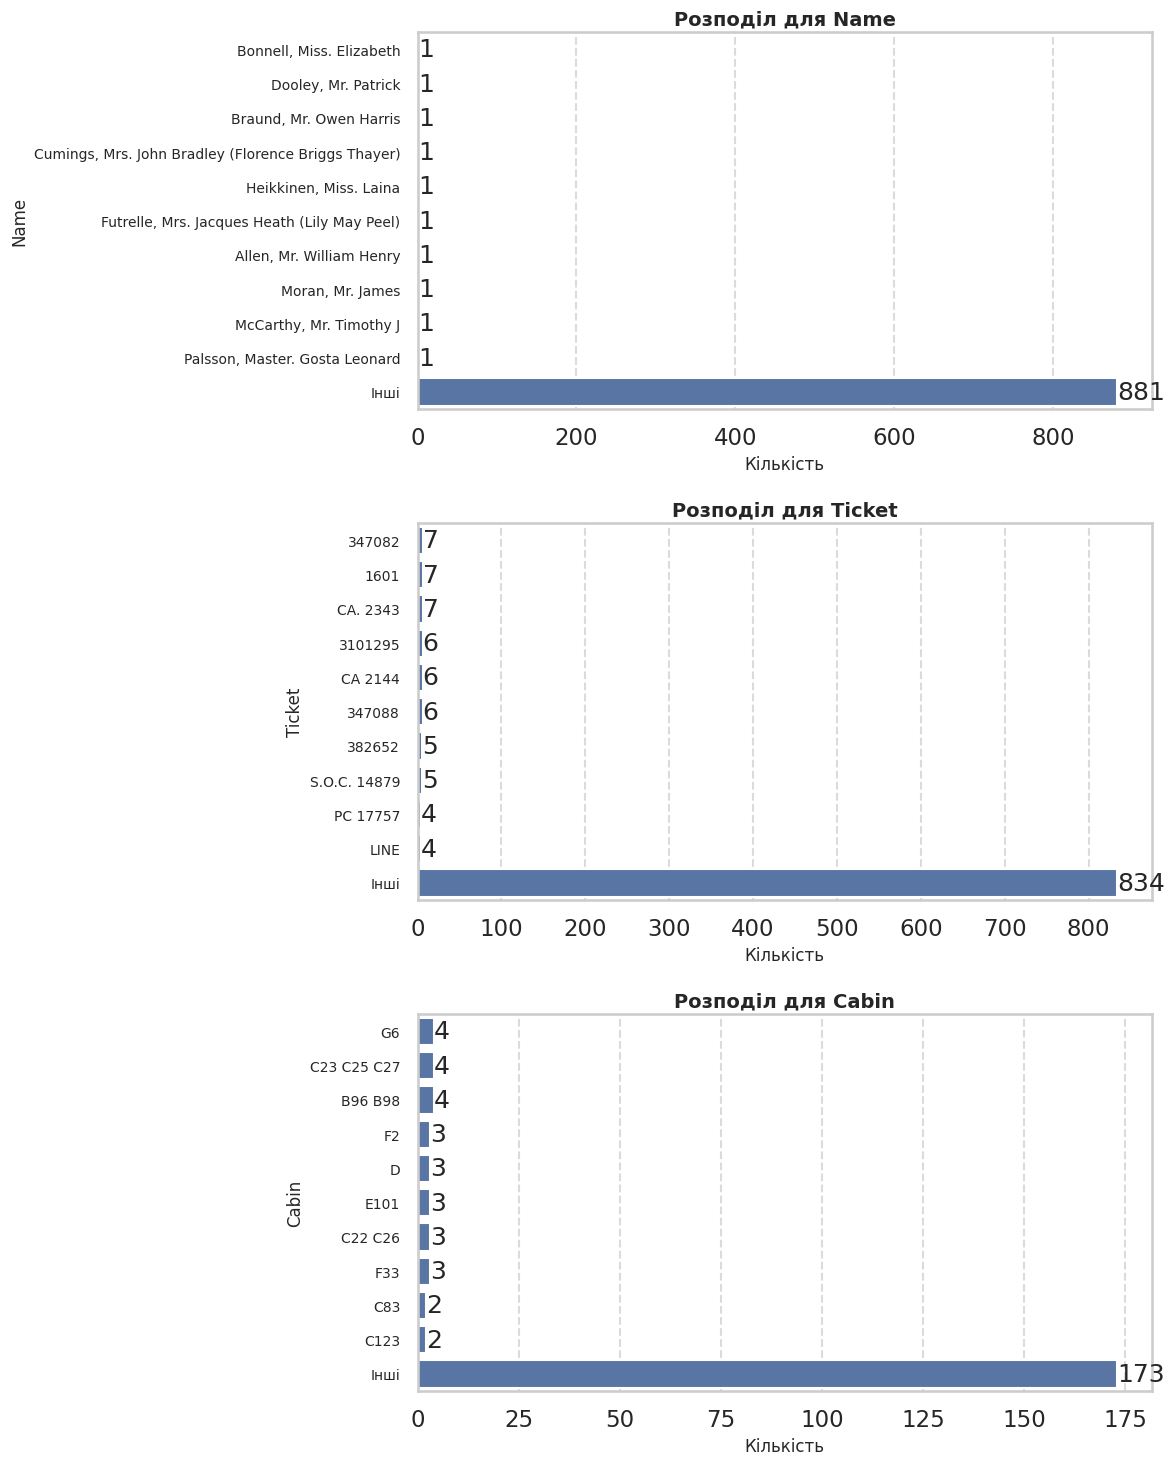

In [ ]:
categorical_columns = dataset.select_dtypes(include=["object"]).columns
n_cols = len(categorical_columns)

fig, axes = plt.subplots(nrows=n_cols, figsize=(12, 5*n_cols))
plt.subplots_adjust(hspace=0.5)

for i, col in enumerate(categorical_columns):
    value_counts = dataset[col].value_counts().sort_values(ascending=False)

    if len(value_counts) > 15:
        top_categories = value_counts.iloc[:10]
        other_count = value_counts.iloc[10:].sum()
        value_counts = pd.concat([top_categories, pd.Series({'Інші': other_count})])

    current_ax = axes[i] if n_cols > 1 else axes

    sns.barplot(x=value_counts.values, y=value_counts.index, ax=current_ax)

    for j, v in enumerate(value_counts.values):
        current_ax.text(v + 0.1, j, str(v), va='center')

    current_ax.set_title(f'Розподіл для {col}', fontsize=14, fontweight='bold')
    current_ax.set_xlabel('Кількість', fontsize=12)
    current_ax.set_ylabel(col, fontsize=12)
    current_ax.tick_params(axis='y', labelsize=10)

    current_ax.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Ваші висновки:
Більшість спостережень потрапляють у групу «Інші», тоді як окремі категорії представлені лише кількома або навіть одним записом.

Дані мають дуже багато унікальних значень з низькою частотою, що може ускладнити аналіз і використання цих ознак при побудові моделей.

***Завдання 11.*** Побудувати діаграми розподілу всіх числових змінних

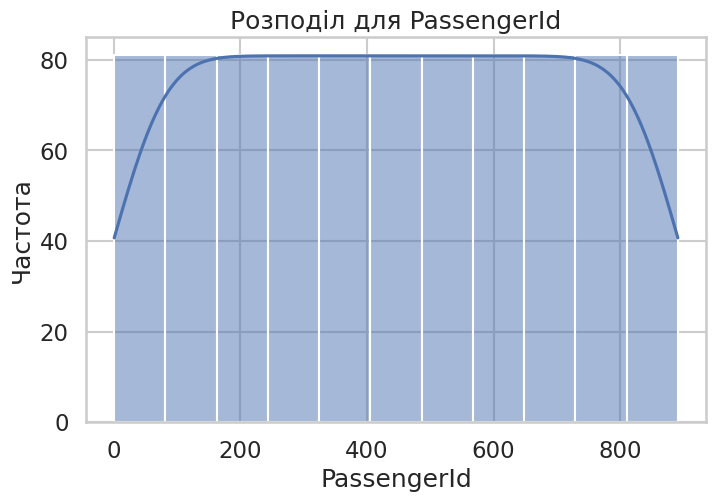

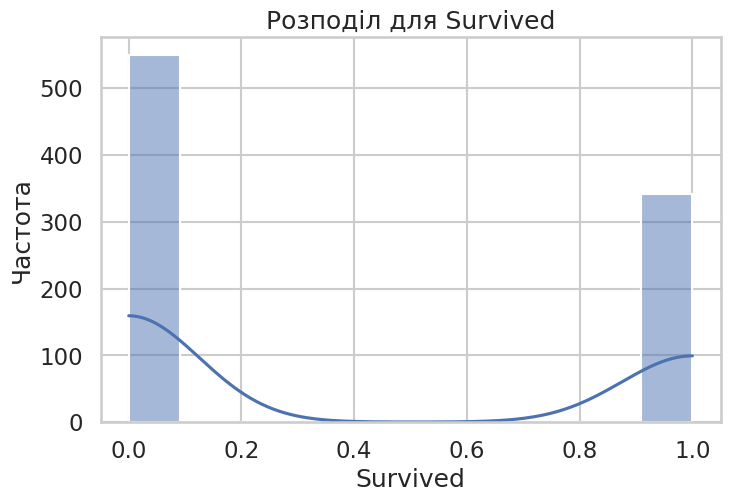

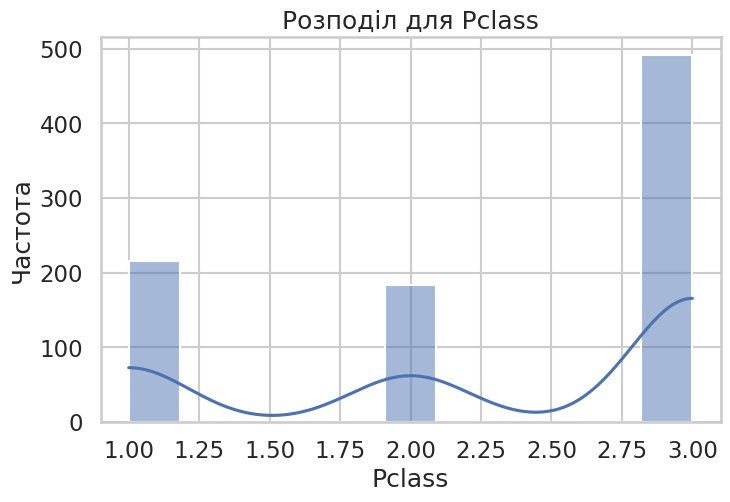

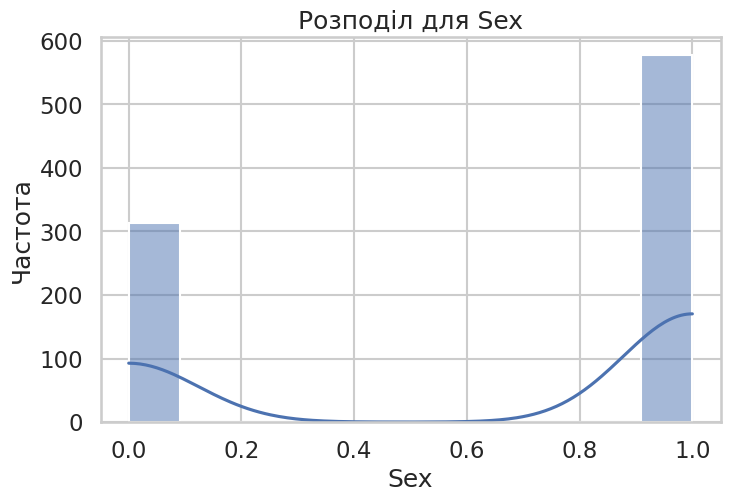

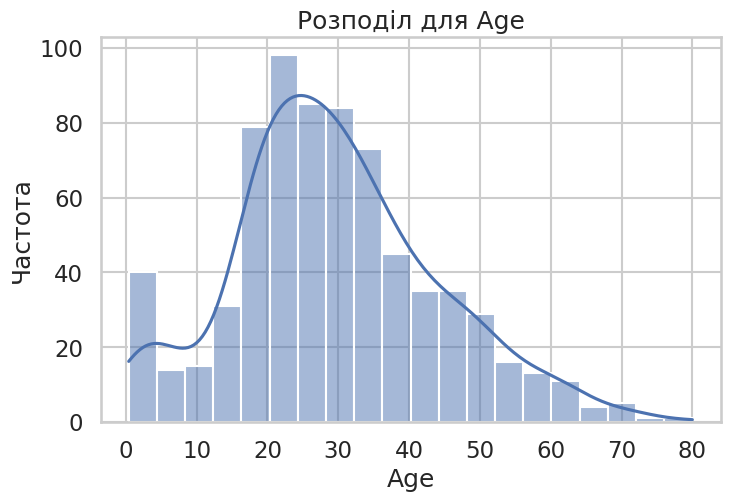

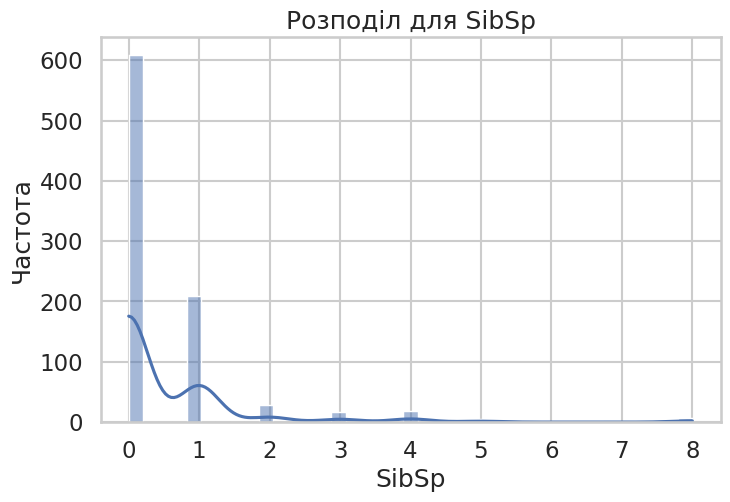

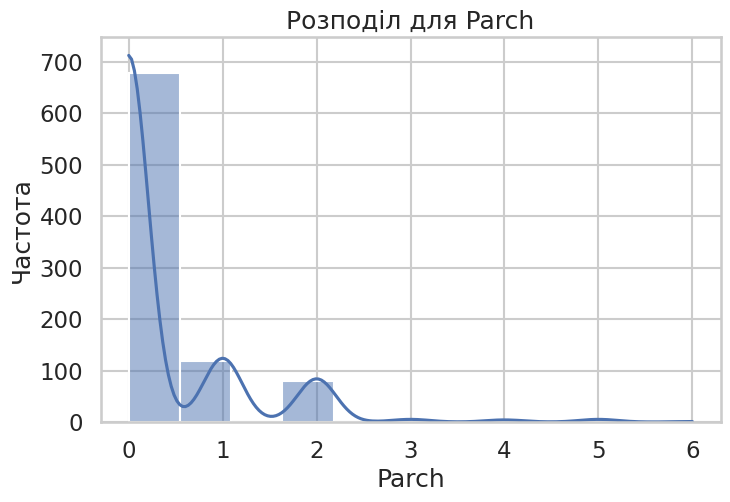

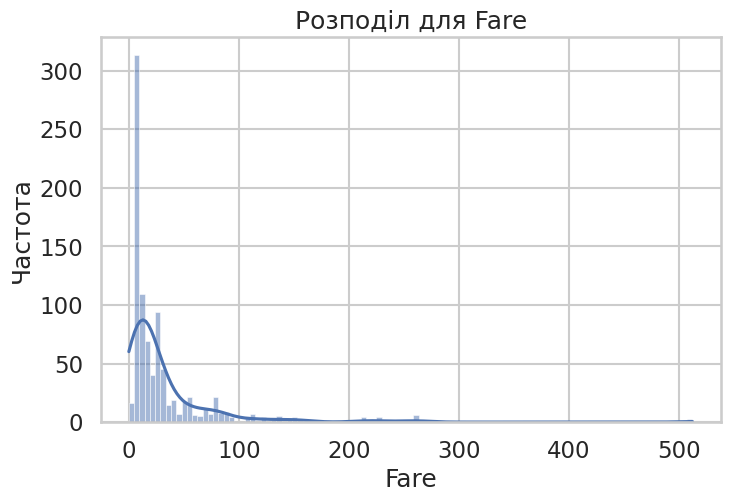

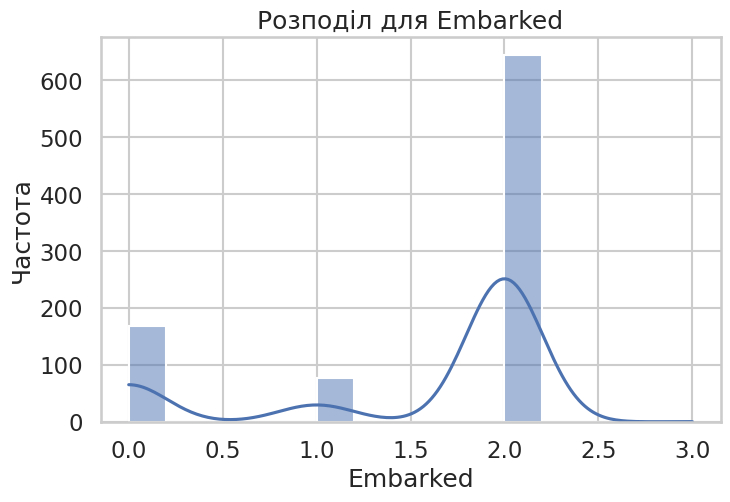

In [ ]:
numerical_columns = dataset.select_dtypes(include=['float64', 'int64']).columns

for col in numerical_columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(dataset[col], kde=True)
    plt.title(f'Розподіл для {col}')
    plt.xlabel(col)
    plt.ylabel('Частота')
    plt.show()

Ваші висновки:
Survived: Більшість пасажирів не вижили, що свідчить про виражену дисбалансність класів у цій змінній.

Pclass: Переважна частка пасажирів віднесена до 3-го класу, у 1-го класу – помірна кількість, а 2-й клас представлений найрідше.

Sex: Статеве кодування показує значну нерівномірність – один з кодів домінує у вибірці, що важливо враховувати при подальшій моделі.

SibSp: Велика частина пасажирів не мали брата, сестри або подружжя на борту, а з підвищенням кількості спостережень різко зменшується кількість записів.

Parch: Подібно до SibSp, більшість записів має значення 0, що свідчить про невелику присутність сімейних зв’язків за даною ознакою.

Fare: Тарифи мають правосторонню асиметрію – переважна маса значень знаходиться у нижньому діапазоні, а високі тарифи зустрічаються рідко; це може вимагати трансформації.

Embarked: Розподіл портів відправлення теж нерівномірний – одна категорія домінує над іншими, що потрібно враховувати при аналізі впливу цієї ознаки.

##Співвіднонешшя між всіма числовими змінними
  
***Завдання 12.*** В деяких випадках візуалізація співвідношення між змінними (числовими, категоріальними) дає можливість побачити викиди в змінних та знайти приховані тенденції і виділити навіть додаткові змінні. Тому, необхідно:
1) побудувати графіки співвідношення між всіма числовими змінними.  
2) описати отримані співвідношення і запропонувати як їх можна (чи не можна) використати

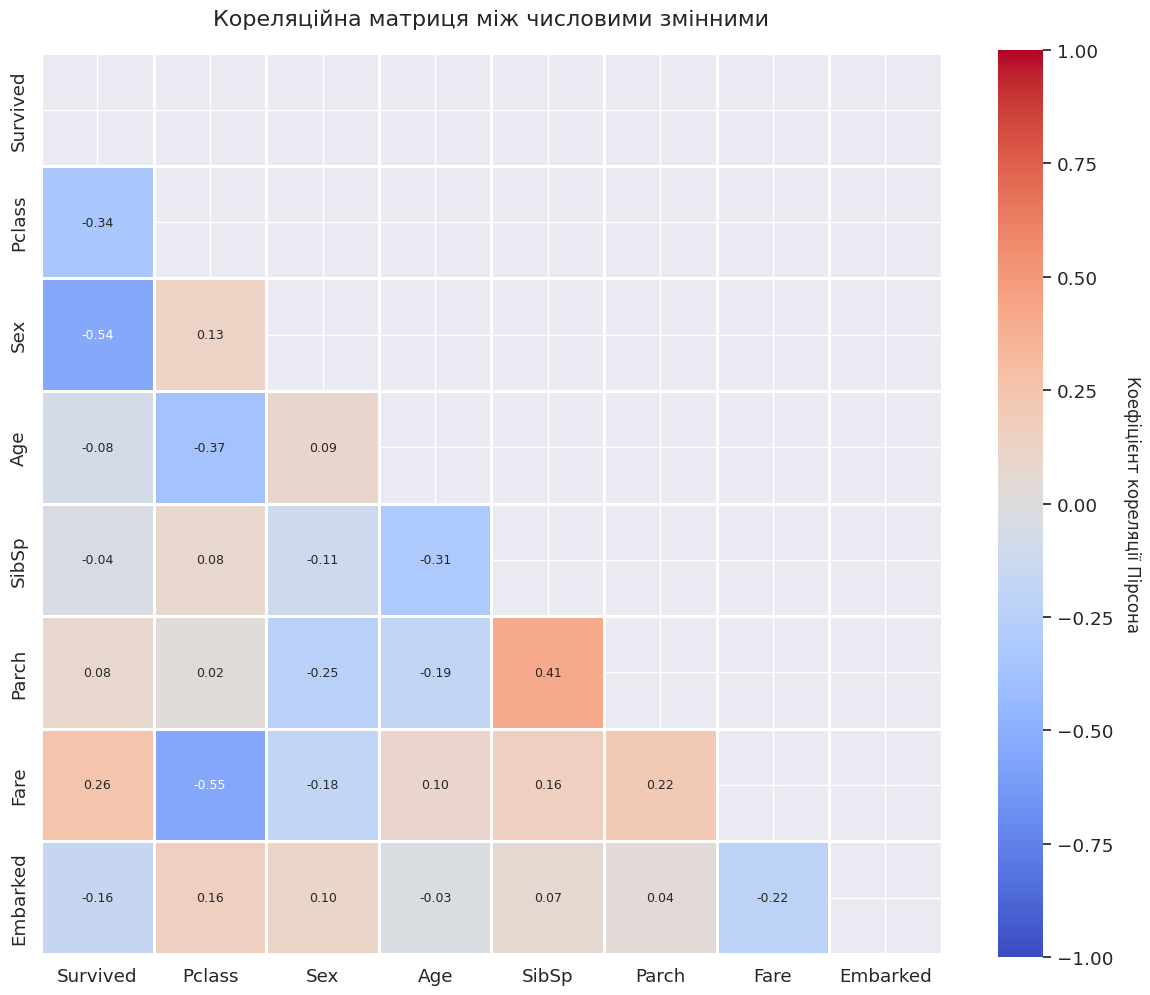

Показуємо парні графіки для 6 найбільш інформативних змінних


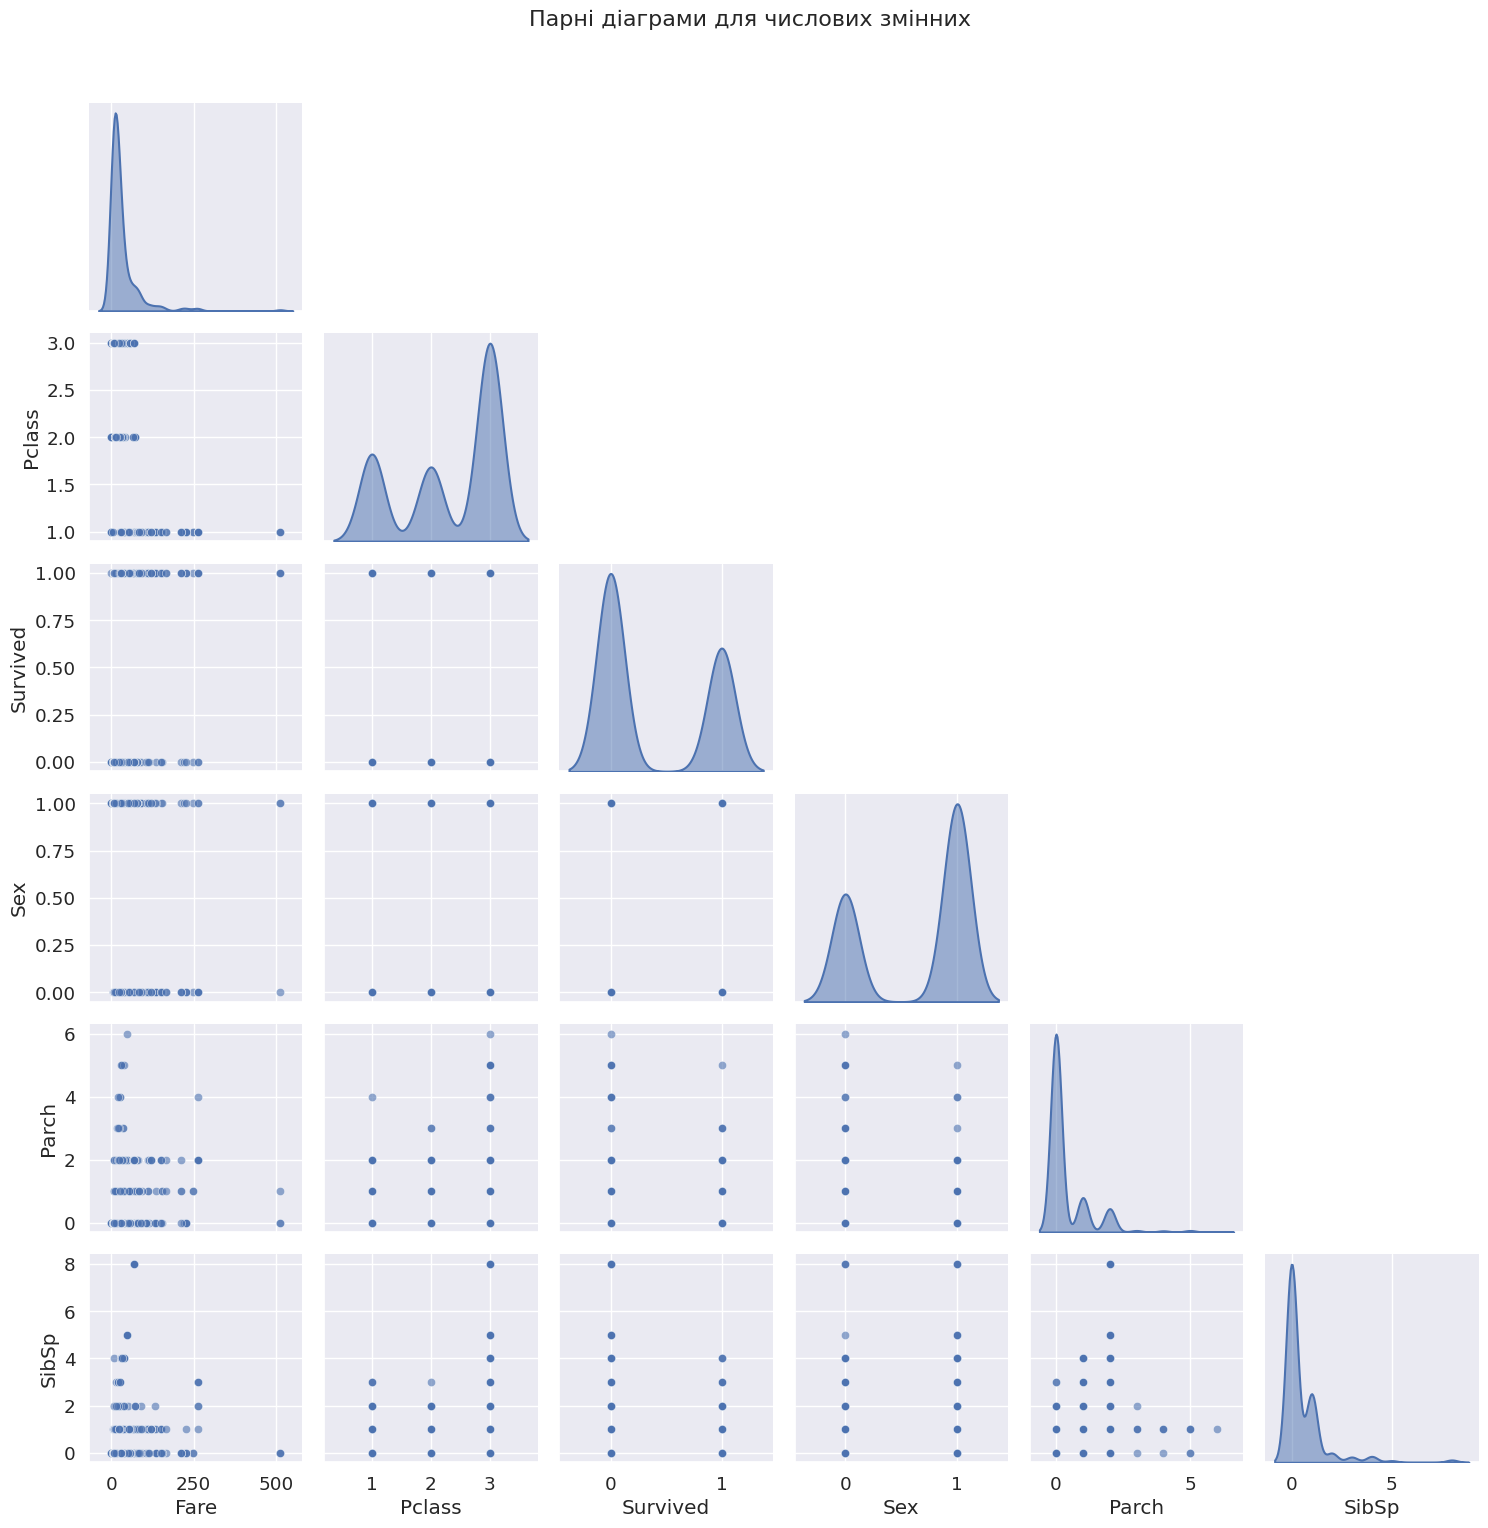

In [ ]:
columns_to_use = [col for col in numerical_columns if col.lower() != 'passengerid']

correlation_matrix = dataset[columns_to_use].corr()

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

plt.figure(figsize=(12, 10))
sns.set(font_scale=1.2)

heatmap = sns.heatmap(
    correlation_matrix,
    annot=True,                     # Показувати значення
    mask=mask,                      # Застосовуємо маску для трикутника
    cmap='coolwarm',                # Кольорова схема
    vmin=-1, vmax=1,                # Діапазон значень
    fmt='.2f',                      # Формат значень (2 знаки після коми)
    linewidths=0.8,                 # Товщина ліній між комірками
    annot_kws={"size": 9},          # Розмір тексту значень
    square=True                     # Квадратні комірки
)

plt.title("Кореляційна матриця між числовими змінними", fontsize=16, pad=20)

cbar = heatmap.collections[0].colorbar
cbar.ax.set_ylabel("Коефіцієнт кореляції Пірсона", rotation=270, labelpad=20, fontsize=12)

for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            plt.text(j+0.5, i+0.5, "✓",
                    ha='center', va='center', color='black', fontsize=15,
                    bbox=dict(facecolor='white', alpha=0.2, edgecolor='none'))

plt.tight_layout()
plt.show()


max_vars = 6
if len(columns_to_use) > max_vars:
    mean_abs_corr = correlation_matrix.abs().mean().sort_values(ascending=False)
    selected_columns = mean_abs_corr.index[:max_vars].tolist()
    print(f"Показуємо парні графіки для {max_vars} найбільш інформативних змінних")
else:
    selected_columns = columns_to_use

g = sns.pairplot(
    dataset[selected_columns],
    diag_kind='kde',
    corner=True,
    plot_kws={'alpha': 0.6},
    diag_kws={'fill': True, 'alpha': 0.5, 'linewidth': 1.5}
)

g.figure.suptitle("Парні діаграми для числових змінних", fontsize=16, y=1.02)
g.figure.tight_layout()
plt.show()

Ваші висновки:
Побудовані парні графіки демонструють чіткі взаємозв’язки між змінними. Наприклад, тариф тісно пов’язаний з класом і впливає на виживання, а сімейні змінні свідчать про потенціал створення нової комбінованої ознаки.

Істограми по діагоналі виявляють асиметрію та можливі викиди, що може вимагати трансформацій для покращення якості даних.

Кожне правильно виконане завдання буде оцінюватись в ```2 бали```.